In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
exoplanet_df = pd.read_csv("exoplanet_data.csv", comment="#")

In [4]:
print(exoplanet_df.shape)
print(exoplanet_df.columns)
#there are 567 rows and 92 columns
#I wish I could say I knew all of these but unfortunately
#I don't know defualt_flag, sy_snum, sy_pnum, disc_facility, soltype
#and pretty much everything after that

(567, 92)
Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1',
       'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2',
       'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2',
       'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2',
       'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1',
       'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1',
       'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2',
       'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1',
       'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 's

- planet name = pl_name - name of the planet
- host name = hostname - name of the star the planet's orbiting around
- discovery method = discoverymethod - how the planet was identified first
- spectral type = st_spectype - what spectral type the star has based on its characteristics
- equilibrium temperature (K) = pl_eqt - "the equilibrium temperature of the planet as modeled by a blackbody heated only by its host star"
- planet mass or mass*sin(i) (Jupiter Mass) = pl_bmasj - the best estimate of the planet's mass, and its measured in Jupiter masses

In [5]:
columns_to_keep = ['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt', 'pl_bmassj']

exoplanet_reduced_df = exoplanet_df[columns_to_keep]

In [6]:
exoplanet_filtered_df = exoplanet_reduced_df.dropna()

In [7]:
print(exoplanet_filtered_df.shape)
print(exoplanet_filtered_df.head())
print(exoplanet_filtered_df.tail())
print(exoplanet_filtered_df.columns)

(67, 6)
    pl_name hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
2  DMPP-1 b   DMPP-1  Radial Velocity        F8 V   877.0   0.076362
3  DMPP-1 c   DMPP-1  Radial Velocity        F8 V  1239.0   0.030205
4  DMPP-1 d   DMPP-1  Radial Velocity        F8 V  1632.0   0.010540
5  DMPP-1 e   DMPP-1  Radial Velocity        F8 V  1314.0   0.012994
6  DMPP-2 b   DMPP-2  Radial Velocity        F5 V  1000.0   0.437000
         pl_name   hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
546   WASP-185 b   WASP-185          Transit        G0 V  1160.0      0.980
549   WASP-190 b   WASP-190          Transit     F6 IV-V  1500.0      1.000
555   WASP-192 b   WASP-192          Transit        G0 V  1620.0      2.300
561       XO-7 b       XO-7          Transit        G0 V  1743.0      0.709
566  eps Ind A b  eps Ind A  Radial Velocity        K5 V   275.0      6.310
Index(['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt',
       'pl_bmassj'],
      dtype='object')


In [8]:
discovery_counts = exoplanet_filtered_df['discoverymethod'].value_counts()
print(discovery_counts)

discoverymethod
Transit            52
Radial Velocity    13
Imaging             2
Name: count, dtype: int64


- discovery methods: transit, radial velocity, and imaging
- transit has the most, while imaging has the least (which makes sense imo)
- transit method: you detect the planet when it passes in front of the host star, causing a dip in the star's brightness
- radial velocity: measure the slight movement of the host star caused by the planet's gravitational pull
- imaging: directly imaging the exoplanet, which can be accomplished by blocking out the bright light of the host star

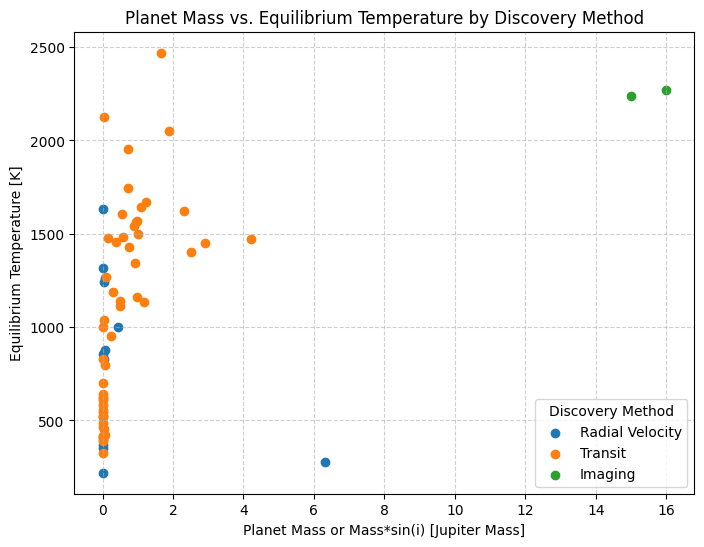

In [10]:
plt.figure(figsize=(8, 6))

discovery_methods = exoplanet_filtered_df['discoverymethod'].unique()

for method in discovery_methods:
    subset = exoplanet_filtered_df[exoplanet_filtered_df['discoverymethod'] == method]
    plt.scatter(
        subset['pl_bmassj'],   # Planet Mass (Jupiter Mass)
        subset['pl_eqt'],      # Equilibrium Temperature (K)
        label=method           # Label for the legend
    )

plt.title('Planet Mass vs. Equilibrium Temperature by Discovery Method')
plt.xlabel('Planet Mass or Mass*sin(i) [Jupiter Mass]')
plt.ylabel('Equilibrium Temperature [K]')
plt.legend(title='Discovery Method')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

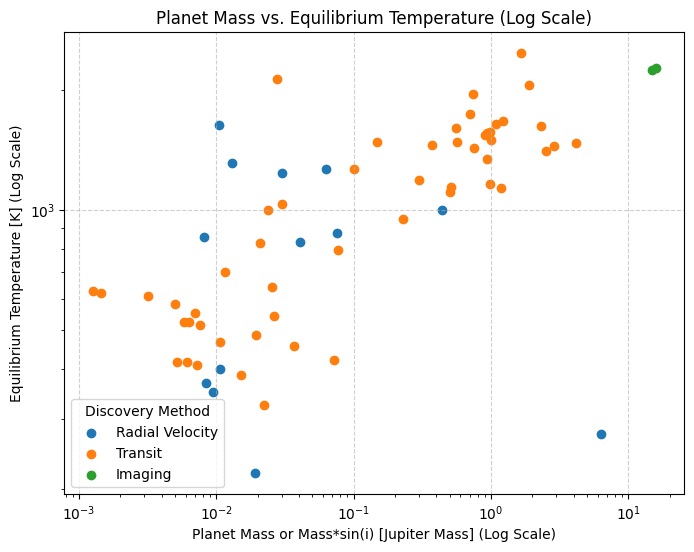

In [11]:
plt.figure(figsize=(8, 6))

discovery_methods = exoplanet_filtered_df['discoverymethod'].unique()

for method in discovery_methods:
    subset = exoplanet_filtered_df[exoplanet_filtered_df['discoverymethod'] == method]
    plt.scatter(
        subset['pl_bmassj'],
        subset['pl_eqt'],
        label=method
    )

plt.xscale('log')
plt.yscale('log')

plt.title('Planet Mass vs. Equilibrium Temperature (Log Scale)')
plt.xlabel('Planet Mass or Mass*sin(i) [Jupiter Mass] (Log Scale)')
plt.ylabel('Equilibrium Temperature [K] (Log Scale)')
plt.legend(title='Discovery Method')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

It appears that only very massive stars are able to be found by the imaging method

In [12]:
massive_planets = exoplanet_filtered_df[exoplanet_filtered_df['pl_bmassj'] > 5]
coldest_massive_index = massive_planets['pl_eqt'].idxmin()
coldest_massive_planet = exoplanet_filtered_df.loc[coldest_massive_index]
print(coldest_massive_planet)

pl_name                eps Ind A b
hostname                 eps Ind A
discoverymethod    Radial Velocity
st_spectype                   K5 V
pl_eqt                       275.0
pl_bmassj                     6.31
Name: 566, dtype: object


In [13]:
#planet name: eps Ind A b
#566
#275.0 K
#6.31 Jupiter masses
#the sun is a type G, while this one is type K, so it's next to the Sun's spectral type
#so I guess it's similar?

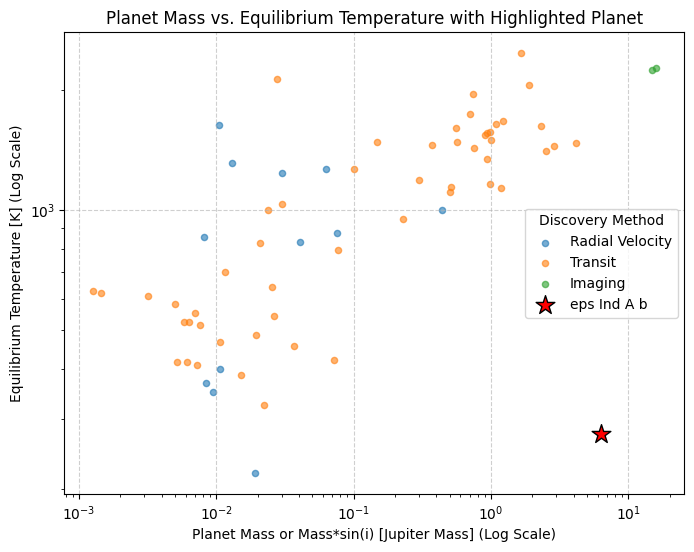

In [15]:
plt.figure(figsize=(8, 6))

planet_name = coldest_massive_planet['pl_name']
planet_mass = coldest_massive_planet['pl_bmassj']
planet_temp = coldest_massive_planet['pl_eqt']

discovery_methods = exoplanet_filtered_df['discoverymethod'].unique()

for method in discovery_methods:
    subset = exoplanet_filtered_df[exoplanet_filtered_df['discoverymethod'] == method]
    plt.scatter(
        subset['pl_bmassj'],
        subset['pl_eqt'],
        label=method,
        s=20, # Set a small size for normal points
        alpha=0.6
    )

plt.scatter(planet_mass, planet_temp, label=planet_name, color='red', marker='*', s=200, edgecolor='black', zorder=5)

plt.xscale('log')
plt.yscale('log')

plt.title('Planet Mass vs. Equilibrium Temperature with Highlighted Planet')
plt.xlabel('Planet Mass or Mass*sin(i) [Jupiter Mass] (Log Scale)')
plt.ylabel('Equilibrium Temperature [K] (Log Scale)')
plt.legend(title='Discovery Method')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()